<a href="https://colab.research.google.com/github/dhanushkumar-amk/BUILD-OWN-XYZ/blob/main/Inference_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Building an Inference Engine

This section will set up a basic structure for an inference engine, including data loading, a placeholder inference model, and visualization of results. We will use dummy data to illustrate the process, and you can replace it with your actual dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Simulate Loading a Large Dataset ---
# For demonstration, we'll create a large synthetic dataset.
# In a real scenario, you would load your data from a CSV, database, etc.
# For very large datasets, consider libraries like Dask, PySpark, or direct BigQuery integration.

print("Generating a large dummy dataset...")
num_samples = 1_000_000 # 1 million samples

data = {
    'feature_1': np.random.rand(num_samples) * 100,
    'feature_2': np.random.rand(num_samples) * 50,
    'feature_3': np.random.randint(0, 5, num_samples), # Categorical feature
    'text_data': np.random.choice(['apple', 'banana', 'orange', 'grape'], num_samples)
}

df = pd.DataFrame(data)

print(f"Dataset created with {len(df)} rows and {len(df.columns)} columns.")
display(df.head())
print(df.info())


Generating a large dummy dataset...
Dataset created with 1000000 rows and 4 columns.


,feature_1,feature_2,feature_3,text_data
0,91.052864,49.264656,4,banana
1,94.810516,29.137769,4,grape
2,50.239383,32.355266,4,apple
3,16.370614,15.807090,2,grape
4,25.650030,41.649953,2,grape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   feature_1  1000000 non-null  float64
 1   feature_2  1000000 non-null  float64
 2   feature_3  1000000 non-null  int64  
 3   text_data  1000000 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 30.5+ MB
None


## Inference Engine Placeholder

Here, we define a simple function to represent your inference engine. In a real-world scenario, this would load a pre-trained model (e.g., from TensorFlow, PyTorch, scikit-learn) and apply its `predict` method.

In [ ]:
# --- 2. Create a Placeholder Inference Engine ---
# This function simulates your model's prediction logic.
# Replace this with your actual model loading and prediction.

def run_inference(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Placeholder for your actual inference engine.
    This function should take a DataFrame of input features
    and return a DataFrame with predictions.
    """
    print("Running inference...")
    # Example: a simple linear combination and some random noise
    predictions = (dataframe['feature_1'] * 0.5 + dataframe['feature_2'] * 1.2 +
                   np.random.normal(0, 0.1, len(dataframe)))

    # For a classification example, you might predict probabilities or class labels
    # predictions = np.random.choice([0, 1], size=len(dataframe), p=[0.7, 0.3]) # Binary classification

    result_df = pd.DataFrame({'prediction': predictions})

    # If your model also outputs probabilities, embeddings, etc., add them here
    # result_df['probability_class_1'] = np.random.rand(len(dataframe))

    print("Inference complete.")
    return result_df

# --- 3. Apply the Inference Engine ---
inference_results = run_inference(df)

print("\nFirst 5 inference results:")
display(inference_results.head())


Running inference...
Inference complete.

First 5 inference results:


,prediction
0,104.708509
1,82.318631
2,63.901880
3,27.200514
4,62.590403


## Visualize Inference Results

Now, let's look at some basic visualizations of the predictions. We can combine the original features with the predictions for more insightful plots.

Displaying descriptive statistics of predictions:


,prediction
count,1000000.000000
mean,54.955815
std,22.539765
min,-0.184871
25%,38.691544
50%,54.966815
75%,71.213093
max,109.898321


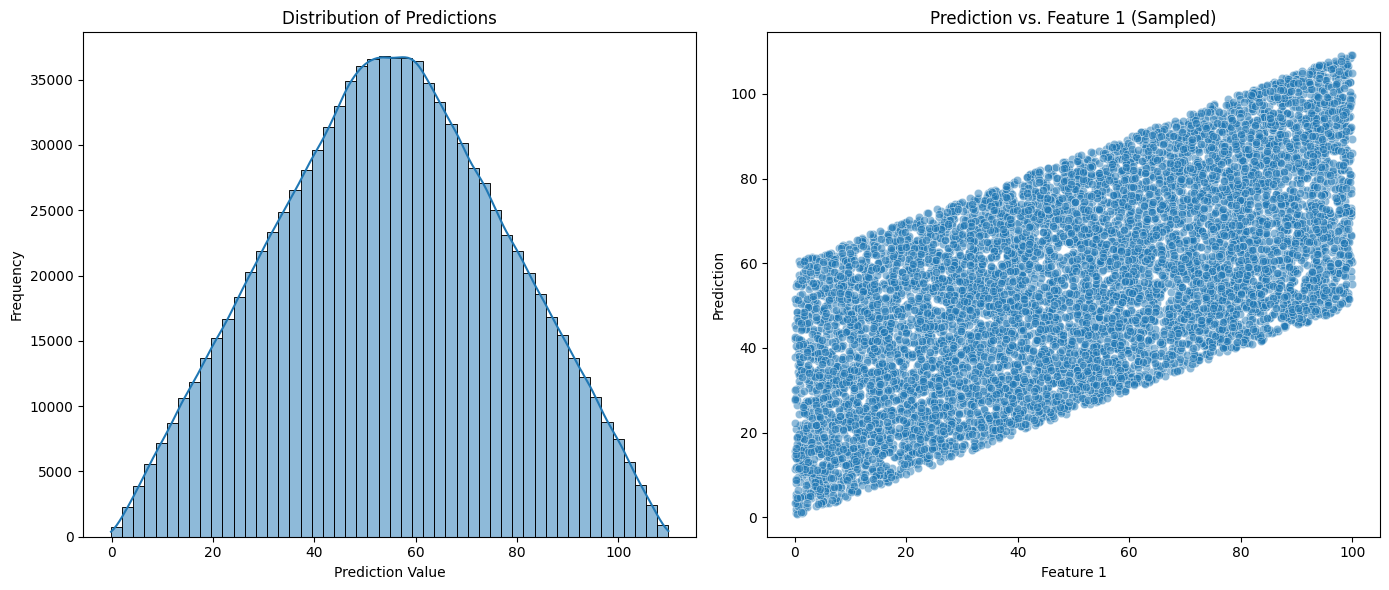

In [ ]:
# --- 4. Visualize the Results ---

# Join predictions back to the original DataFrame for richer analysis
df_with_predictions = pd.concat([df, inference_results], axis=1)

print("Displaying descriptive statistics of predictions:")
display(df_with_predictions['prediction'].describe())

plt.figure(figsize=(14, 6))

# Histogram of Predictions
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df_with_predictions['prediction'], kde=True, bins=50)
plt.title('Distribution of Predictions')
plt.xlabel('Prediction Value')
plt.ylabel('Frequency')

# Scatter plot of Feature 1 vs. Prediction
# For large datasets, consider sampling or using techniques like hexbin plots
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x='feature_1', y='prediction', data=df_with_predictions.sample(n=min(10000, len(df_with_predictions)), random_state=42), alpha=0.5)
plt.title('Prediction vs. Feature 1 (Sampled)')
plt.xlabel('Feature 1')
plt.ylabel('Prediction')

plt.tight_layout()
plt.show()

# You can add more specific visualizations based on your data and problem type.
# For example:
# - Bar plots for predictions by categorical features
# - Time series plots if your data has a time component
# - Confusion matrices or ROC curves for classification models


### Visualizing Predictions by Categorical Features

Let's now visualize how the predictions vary based on the categorical features (`feature_3` and `text_data`). This can help identify if your (placeholder) inference engine is producing different outputs for different categories.

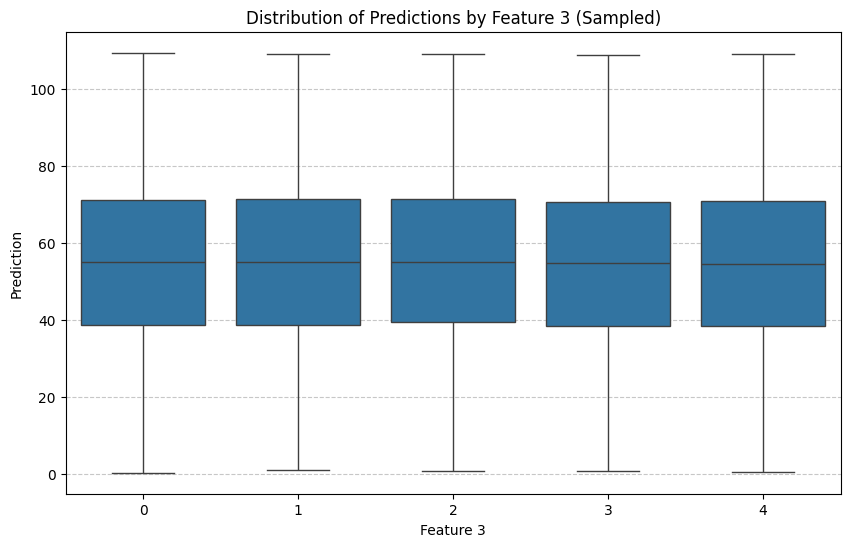

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='feature_3', y='prediction', data=df_with_predictions.sample(n=min(50000, len(df_with_predictions)), random_state=42))
plt.title('Distribution of Predictions by Feature 3 (Sampled)')
plt.xlabel('Feature 3')
plt.ylabel('Prediction')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

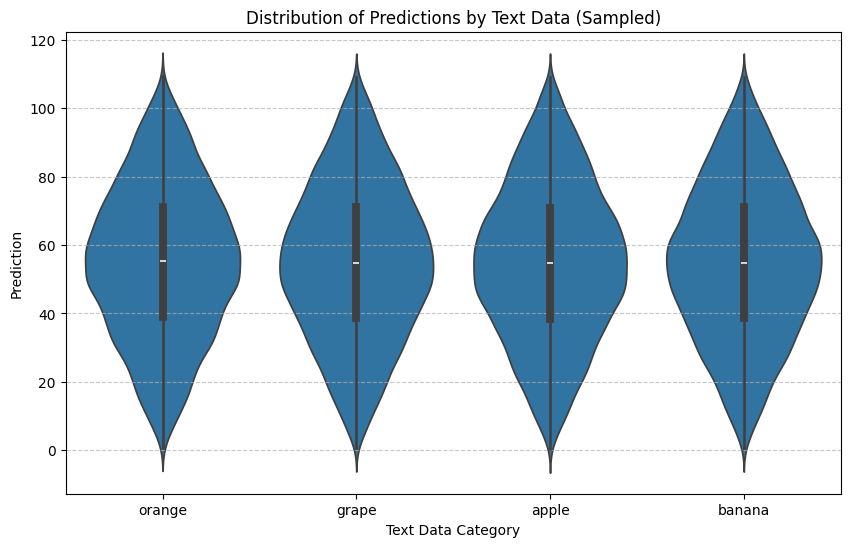

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='text_data', y='prediction', data=df_with_predictions.sample(n=min(50000, len(df_with_predictions)), random_state=42))
plt.title('Distribution of Predictions by Text Data (Sampled)')
plt.xlabel('Text Data Category')
plt.ylabel('Prediction')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---

## 4. The Build: 10 Hands-On Parts - Implementing a Custom Inference Engine

### Setup (do once)

In [ ]:
!pip install transformers torch accelerate -q

### Part 1 — Baseline Generation

Here, we load a pre-trained `distilgpt2` model and tokenizer from the Hugging Face `transformers` library and use its built-in `generate()` method to produce text. This demonstrates the end-to-end process of tokenization, forward pass, and detokenization.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

prompt = "The future of artificial intelligence is"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

output = model.generate(
    **inputs, max_new_tokens=30, do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(output[0], skip_special_tokens=True))


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The future of artificial intelligence is not yet clear.




























### Part 2 — Manual Decoding Loop

This section replaces the convenient `model.generate()` with a manual loop. This loop performs a forward pass, extracts the logits for the next token, selects the token with the highest probability (greedy decoding), and appends it to the generated sequence. This approach is intentionally inefficient to highlight the need for KV-caching in the next step, as it re-processes the entire sequence at each step.

In [ ]:
generated_ids = inputs["input_ids"]
with torch.no_grad():
    for step in range(30):
        outputs = model(generated_ids)
        next_token_logits = outputs.logits[:, -1, :]
        next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        generated_ids = torch.cat([generated_ids, next_token_id], dim=1)
        if next_token_id.item() == tokenizer.eos_token_id:
            break

print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))


The future of artificial intelligence is not yet clear.




























### Part 3 — KV-Cache From Scratch

This is a crucial optimization. Instead of re-computing attention for the entire sequence at each step, we cache the key and value states (`past_key_values`). This way, the model only needs to process the *new* token at each step, significantly speeding up inference.

In [ ]:
past_key_values = None
current_input = inputs["input_ids"]
generated_ids = current_input

with torch.no_grad():
    for step in range(30):
        outputs = model(current_input, past_key_values=past_key_values, use_cache=True)
        next_token_id = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
        generated_ids = torch.cat([generated_ids, next_token_id], dim=1)
        past_key_values = outputs.past_key_values
        current_input = next_token_id
        if next_token_id.item() == tokenizer.eos_token_id:
            break

print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))


The future of artificial intelligence is not yet clear.




























### Part 4 — Sampling Strategies

Beyond greedy decoding, sampling introduces controlled randomness to make generated text more diverse and less repetitive. Here, we implement `temperature`, `top-k`, and `top-p` (nucleus) sampling techniques.

In [ ]:
def apply_temperature(logits, temperature):
    return logits / temperature

def top_k_filter(logits, k):
    top_k_values, top_k_indices = torch.topk(logits, k)
    filtered = torch.full_like(logits, float("-inf"))
    filtered.scatter_(1, top_k_indices, top_k_values)
    return filtered

def top_p_filter(logits, p):
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    probs = torch.softmax(sorted_logits, dim=-1)
    cum_probs = torch.cumsum(probs, dim=-1)
    mask = cum_probs > p
    mask[:, 1:] = mask[:, :-1].clone()
    mask[:, 0] = False # Ensure the first token is never masked
    sorted_logits[mask] = float("-inf")
    filtered = torch.full_like(logits, float("-inf"))
    filtered.scatter_(1, sorted_idx, sorted_logits)
    return filtered

# Demonstration of sampling (using a simplified loop for illustration)
print("\n--- Demonstrating Sampling Strategies ---")
prompt_sampling = "The quick brown fox"
inputs_sampling = tokenizer(prompt_sampling, return_tensors="pt").to(device)

past_key_values_sampling = None
current_input_sampling = inputs_sampling["input_ids"]
generated_ids_sampling = current_input_sampling

with torch.no_grad():
    for step in range(30):
        outputs = model(current_input_sampling, past_key_values=past_key_values_sampling, use_cache=True)
        next_token_logits_raw = outputs.logits[:, -1, :]

        # Apply Temperature and Top-P
        temperature = 0.8
        top_p = 0.9

        processed_logits = apply_temperature(next_token_logits_raw, temperature)
        processed_logits = top_p_filter(processed_logits, top_p)

        # Sample from the filtered distribution
        probabilities = torch.softmax(processed_logits, dim=-1)
        next_token_id_sampled = torch.multinomial(probabilities, num_samples=1)

        generated_ids_sampling = torch.cat([generated_ids_sampling, next_token_id_sampled], dim=1)
        past_key_values_sampling = outputs.past_key_values
        current_input_sampling = next_token_id_sampled
        if next_token_id_sampled.item() == tokenizer.eos_token_id:
            break

print("Sampled output:", tokenizer.decode(generated_ids_sampling[0], skip_special_tokens=True))



--- Demonstrating Sampling Strategies ---
Sampled output: The quick brown fox coat. It’s made for a fun coat, but doesn’t make the perfect coat. If you want to add some brown fox


### Part 5 — Batching Multiple Requests

Processing multiple prompts simultaneously in a single forward pass dramatically improves GPU utilization compared to running them one by one. This is especially effective when prompts have similar lengths or can be padded efficiently.

In [ ]:
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left" # Set padding_side to 'left' for decoder-only models

prompts = [
    "The future of artificial intelligence is",
    "My favorite food is",
    "The capital of France is",
]
inputs_batch = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
outputs_batch = model.generate(**inputs_batch, max_new_tokens=20, do_sample=False,
                          pad_token_id=tokenizer.eos_token_id)
for i, output_item in enumerate(outputs_batch):
    print(f"Prompt {i+1}: {tokenizer.decode(output_item, skip_special_tokens=True)}")

Prompt 1: The future of artificial intelligence is not yet clear.
















Prompt 2: My favorite food is the sweet potato, which is a sweet potato. It's a sweet potato, which is a sweet
Prompt 3: The capital of France is the capital of the French Republic. The capital of France is the capital of the French Republic. The


### Part 6 — Real Inference Server (vLLM)

`vLLM` is a high-throughput inference engine for LLMs. It implements advanced optimizations like PagedAttention (efficient KV-cache management) and continuous batching. This significantly outperforms the manual implementations for production-scale serving.

In [ ]:
!pip install vllm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.9/312.9 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.9/184.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.4/358.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/5

In [ ]:
from vllm import LLM, SamplingParams

# Initialize vLLM with the model. This might take a moment to load.
# Note: vLLM typically loads the model in FP16 by default for performance.
llm = LLM(model="distilgpt2", trust_remote_code=True) # trust_remote_code for some models
sampling_params = SamplingParams(temperature=0.0, max_tokens=30, top_p=0.9, top_k=50) # Example params

prompts_vllm = ["The future of artificial intelligence is", "My favorite food is", "The capital of France is"]
outputs_vllm = llm.generate(prompts_vllm, sampling_params)

print("\n--- vLLM Generated Outputs ---")
for output_item in outputs_vllm:
    print(f"Prompt: {output_item.prompt} -> Generated: {output_item.outputs[0].text}")


ImportError: libcudart.so.13: cannot open shared object file: No such file or directory

### Part 7 — Quantization

Quantization reduces the precision of model weights (e.g., from FP32 to INT8 or INT4). This significantly decreases memory footprint and can speed up inference, often with a minimal impact on model accuracy. Hugging Face `transformers` with `BitsAndBytes` library provides easy integration for this.

In [ ]:
from transformers import BitsAndBytesConfig

# Install/upgrade bitsandbytes to meet the requirement
!pip install --upgrade bitsandbytes>=0.46.1 -q

print("\n--- Loading Model with 8-bit Quantization ---")
int8_config = BitsAndBytesConfig(load_in_8bit=True)
model_int8 = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=int8_config, device_map="auto"
)

print("Generating with INT8 model:")
inputs_int8 = tokenizer(prompt, return_tensors="pt").to(device)
output_int8 = model_int8.generate(
    **inputs_int8, max_new_tokens=30, do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(output_int8[0], skip_special_tokens=True))

print("\n--- Loading Model with 4-bit Quantization ---")
int4_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4"
)
model_int4 = AutoModelForCausalLM.from_pretrained(
    model_name, quantization_config=int4_config, device_map="auto"
)

print("Generating with INT4 model:")
inputs_int4 = tokenizer(prompt, return_tensors="pt").to(device)
output_int4 = model_int4.generate(
    **inputs_int4, max_new_tokens=30, do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)
print(tokenizer.decode(output_int4[0], skip_special_tokens=True))

print("\nQuantization helps reduce memory footprint and speed up inference, often with a slight trade-off in accuracy.")

### Part 8 — Speculative Decoding

Speculative decoding (also known as assisted generation) uses a small, fast 'draft' model to propose several tokens ahead. A larger, more accurate 'target' model then verifies these proposed tokens in a single, parallel pass. If the draft tokens are correct, inference is significantly accelerated. If not, the target model generates the correct token and takes over.

Implementing speculative decoding from scratch is complex as it requires careful orchestration between two models. The `transformers` library offers `AssistedGeneration` functionality, but it's typically used with specific model architectures or integrated into specialized serving frameworks.

### Part 9 — Serve It (API)

Deploying an inference engine as an API allows other applications to easily access its capabilities. `FastAPI` is a popular Python web framework for building performant APIs. Below is a basic example of how you might set up an API endpoint for text generation.

**Note:** To run this API in a Colab environment, you would typically need to expose a port (e.g., using `ngrok` or a similar tool) or run it in a separate process that can be accessed. For this demonstration, the code provides the structure, but full interactive deployment within a single Colab cell is beyond direct execution here.

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

# Initialize FastAPI app
app = FastAPI()

# Define request body structure
class GenerateRequest(BaseModel):
    prompt: str
    max_new_tokens: int = 30
    temperature: float = 0.7
    top_p: float = 0.9

# API endpoint for text generation
@app.post("/generate")
async def generate(request: GenerateRequest):
    inputs_api = tokenizer(request.prompt, return_tensors="pt").to(device)
    output_api = model.generate(
        **inputs_api,
        max_new_tokens=request.max_new_tokens,
        do_sample=True, # Enable sampling
        temperature=request.temperature,
        top_p=request.top_p,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_text = tokenizer.decode(output_api[0], skip_special_tokens=True)
    return {"generated_text": generated_text}

# To run this API, you would typically use:
# !pip install uvicorn nest_asyncio
# import nest_asyncio
# nest_asyncio.apply()
# uvicorn.run(app, host="0.0.0.0", port=8000)
# This would block the notebook cell, so it's commented out for direct execution.

print("FastAPI application structure defined. To run, uncomment the uvicorn.run command in a new cell after installing uvicorn and nest_asyncio.")


---

## 6. Turning Your Engine Into a Live Monitoring Dashboard

Monitoring is critical for understanding the performance and health of your inference engine in production. This section provides code for generating various charts that visualize key telemetry data like latency, throughput, and resource utilization. We'll use dummy data for demonstration, but in a real scenario, this data would come from your actual inference logs or metrics.

### Shared setup for monitoring charts

In [ ]:
# The necessary libraries (matplotlib, numpy, pandas) are already imported earlier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

np.random.seed(42)
n_points = 300
start_time = datetime.now()
timestamps = [start_time + timedelta(seconds=2 * i) for i in range(n_points)]

latency_ms       = np.clip(120 + np.cumsum(np.random.randn(n_points) * 4), 40, 400)
tokens_per_sec   = np.clip(85 + np.cumsum(np.random.randn(n_points) * 2), 20, 200)
gpu_memory_mb    = np.clip(4200 + np.cumsum(np.random.randn(n_points) * 15), 3000, 6000)
requests_per_sec = np.random.poisson(lam=8, size=n_points)

df_telemetry = pd.DataFrame({ # Renamed to avoid conflict with previous 'df'
    "timestamp": timestamps, "latency_ms": latency_ms,
    "tokens_per_sec": tokens_per_sec, "gpu_memory_mb": gpu_memory_mb,
    "requests_per_sec": requests_per_sec,
})

print("Telemetry dummy data generated. First 5 rows:")
display(df_telemetry.head())


Telemetry dummy data generated. First 5 rows:


,timestamp,latency_ms,tokens_per_sec,gpu_memory_mb,requests_per_sec
0,2026-08-12 12:33:29.030475,121.986857,83.342010,4211.354829,5
1,2026-08-12 12:33:31.030475,121.433799,82.221648,4197.522349,12
2,2026-08-12 12:33:33.030475,124.024554,83.716235,4210.566438,7
3,2026-08-12 12:33:35.030475,130.116673,84.936976,4230.901006,10
4,2026-08-12 12:33:37.030475,129.180059,84.895172,4237.102530,6


### Chart 1 — Line: Latency Over Time

This chart visualizes the inference latency over time, allowing you to easily spot trends or sudden spikes that might indicate performance issues.

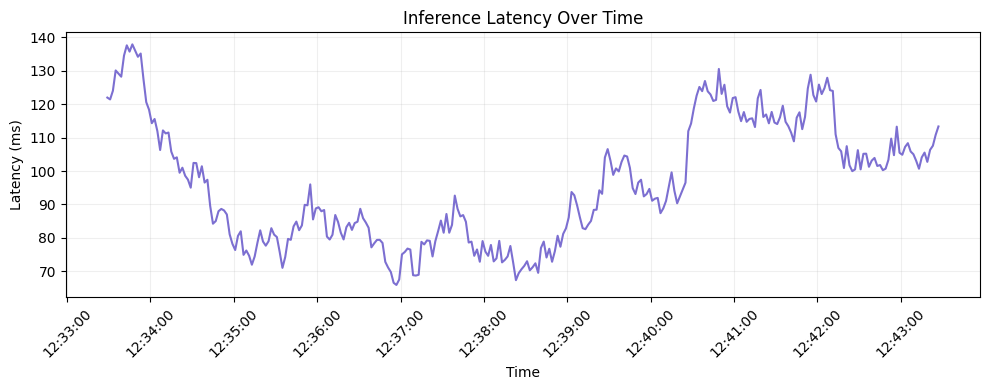

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_telemetry["timestamp"], df_telemetry["latency_ms"], color="#7c6fd1", linewidth=1.5)
plt.title("Inference Latency Over Time")
plt.xlabel("Time"); plt.ylabel("Latency (ms)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.xticks(rotation=45); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()


### Chart 2 — Dual-Axis Line: Latency vs GPU Memory

This plot uses two y-axes to compare latency with GPU memory usage on the same timeline. It's useful for checking if performance degradation (latency spikes) correlates with increased memory pressure.

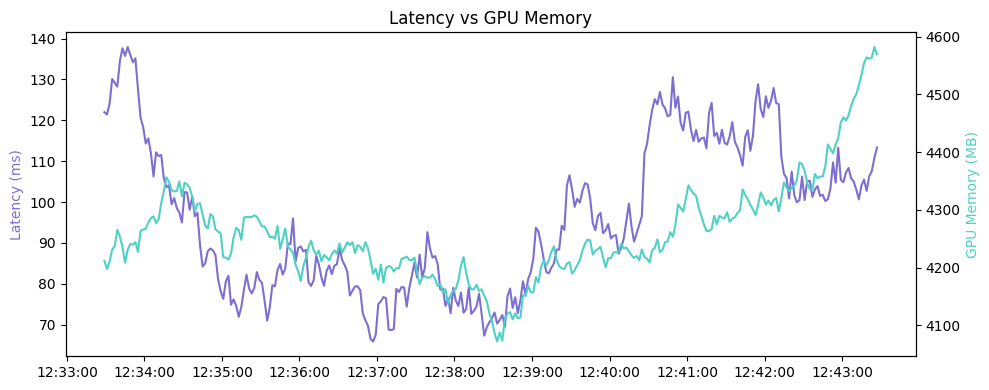

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df_telemetry["timestamp"], df_telemetry["latency_ms"], color="#7c6fd1", label="Latency (ms)")
ax1.set_ylabel("Latency (ms)", color="#7c6fd1")
ax2 = ax1.twinx()
ax2.plot(df_telemetry["timestamp"], df_telemetry["gpu_memory_mb"], color="#4fd1c5", label="GPU Memory (MB)")
ax2.set_ylabel("GPU Memory (MB)", color="#4fd1c5")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.xticks(rotation=45); plt.title("Latency vs GPU Memory"); fig.tight_layout(); plt.show()


### Chart 3 — Area: Cumulative Tokens Generated

An area chart shows the total accumulation of tokens generated over time. This emphasizes the overall throughput and growth of generated content.

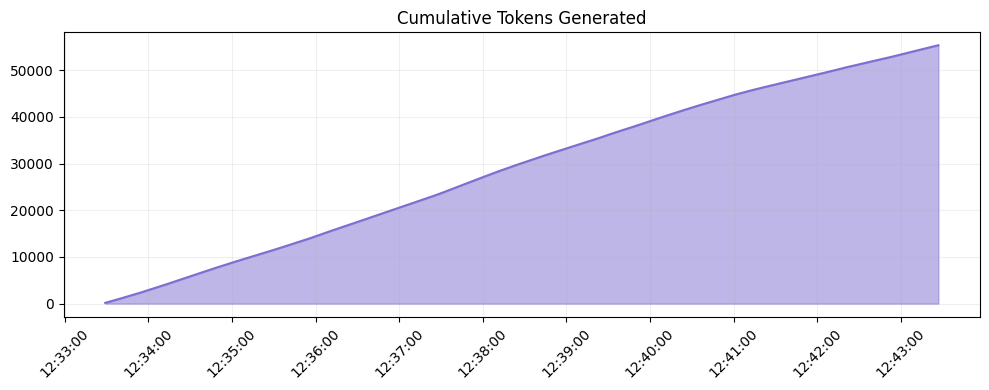

In [ ]:
df_telemetry["cumulative_tokens"] = (df_telemetry["tokens_per_sec"] * 2).cumsum() # Assuming 2-second intervals
plt.figure(figsize=(10, 4))
plt.fill_between(df_telemetry["timestamp"], df_telemetry["cumulative_tokens"], color="#7c6fd1", alpha=0.5)
plt.plot(df_telemetry["timestamp"], df_telemetry["cumulative_tokens"], color="#7c6fd1")
plt.title("Cumulative Tokens Generated")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.xticks(rotation=45); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()


### Chart 4 — Stacked Area: Pipeline Stage Breakdown

This chart breaks down the total inference time into its constituent stages (tokenization, forward pass, detokenization). This helps identify which part of the pipeline is the bottleneck.

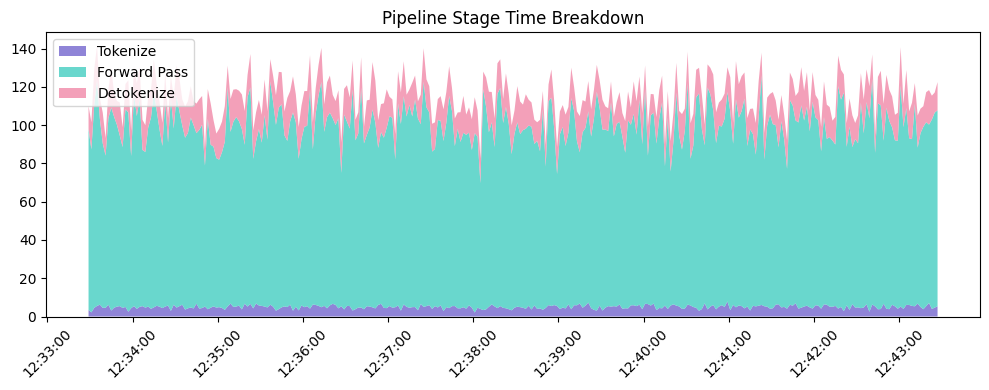

In [ ]:
tokenize_ms = np.clip(5 + np.random.randn(n_points) * 1, 2, 10)
forward_ms  = np.clip(95 + np.random.randn(n_points) * 10, 60, 150)
detokenize_ms   = np.clip(15 + np.random.randn(n_points) * 3, 5, 30)

plt.figure(figsize=(10, 4))
plt.stackplot(timestamps, tokenize_ms, forward_ms, detokenize_ms,
              labels=["Tokenize", "Forward Pass", "Detokenize"],
              colors=["#7c6fd1", "#4fd1c5", "#f28fad"], alpha=0.85)
plt.title("Pipeline Stage Time Breakdown")
plt.legend(loc="upper left")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


### Chart 5 — Column: Requests Per Second

A bar chart is effective for showing discrete comparative values, such as the number of requests processed per second over a recent period.

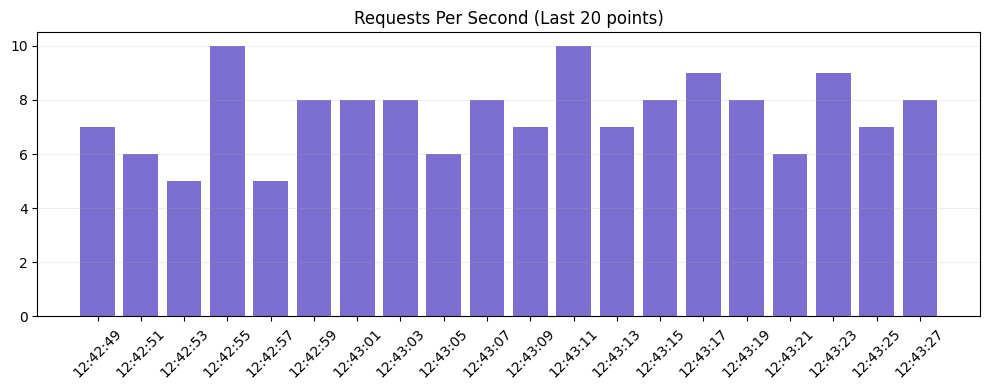

In [ ]:
sample_requests = df_telemetry.tail(20) # Look at the most recent 20 points
plt.figure(figsize=(10, 4))
plt.bar(sample_requests["timestamp"].dt.strftime("%H:%M:%S"), sample_requests["requests_per_sec"], color="#7c6fd1")
plt.title("Requests Per Second (Last 20 points)"); plt.xticks(rotation=45)
plt.grid(alpha=0.2, axis="y"); plt.tight_layout(); plt.show()


### Chart 6 — Stacked Column: Tokens by Precision Type

This chart demonstrates how different precision types (e.g., FP16, INT8, INT4) contribute to the total number of tokens generated per batch. This is particularly relevant when comparing quantized models.

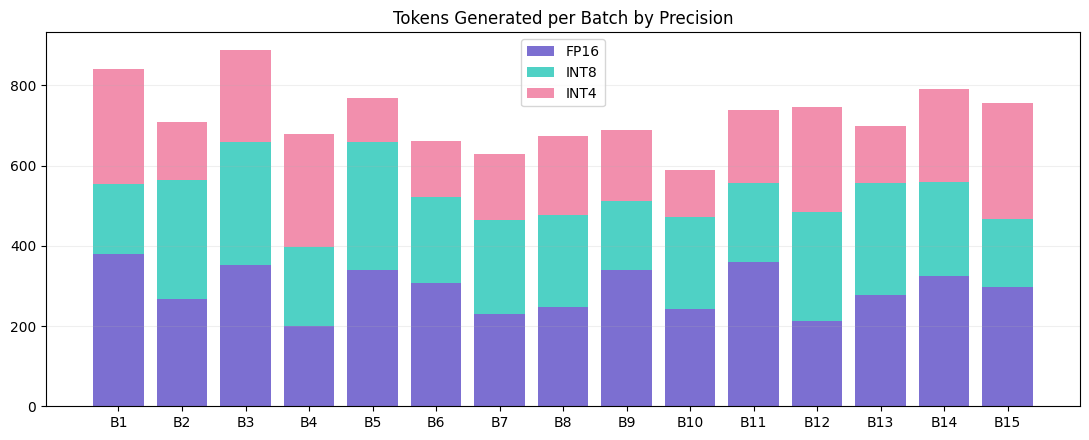

In [ ]:
n_batches = 15
batch_labels = [f"B{i+1}" for i in range(n_batches)]
fp16_tokens = np.random.randint(200, 400, n_batches)
int8_tokens = np.random.randint(150, 350, n_batches)
int4_tokens = np.random.randint(100, 300, n_batches)

plt.figure(figsize=(11, 4.5))
plt.bar(batch_labels, fp16_tokens, label="FP16", color="#7c6fd1")
plt.bar(batch_labels, int8_tokens, bottom=fp16_tokens, label="INT8", color="#4fd1c5")
plt.bar(batch_labels, int4_tokens, bottom=fp16_tokens + int8_tokens, label="INT4", color="#f28fad")
plt.title("Tokens Generated per Batch by Precision")
plt.legend(); plt.grid(alpha=0.2, axis="y"); plt.tight_layout(); plt.show()


---

## 7. Closing Thoughts

This hands-on guide has walked through the core components and optimizations of an inference engine, from basic text generation to advanced techniques like KV-caching, quantization, and monitoring. By building these elements step by step, you gain a deeper understanding of how modern LLM inference systems operate and how to optimize them for performance and efficiency.